# Phase 6 checkpoint: the optimizer

COOLBLOCK-BUILD-PLAN.md §6.5: submodular maximization under a knapsack
constraint. Real candidates (Phase 4/5's rule layer + impervious
candidates, 4,371 total, each already carrying its C1/C2/C3 impact score
and D4 EWCB), a real coverage objective (E1), and three real solvers
(E2): CELF lazy greedy, exact MILP via HiGHS, and a bounded local search.
Plus E3's constraints, E4's efficient frontier, and E5's baselines --
"the proof the product works."

See `docs/METHODOLOGY.md`'s optimizer section for the full narrative;
this notebook re-derives its headline numbers directly from the code, not
by re-typing them.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from engine.impact.albedo import run_albedo_model
from engine.impact.cooling_kernel import run_cooling_kernel
from engine.optimize.objective import build_coverage_objective
from engine.surface.candidates import generate_candidates
from engine.surface.impervious_candidates import generate_impervious_candidates

tree_scored, calibration = run_cooling_kernel(generate_candidates())
impervious_scored, energy_inputs, design_day = run_albedo_model(generate_impervious_candidates())
candidates = gpd.GeoDataFrame(
    pd.concat([tree_scored, impervious_scored], ignore_index=True),
    geometry="geometry",
    crs=tree_scored.crs,
)
print(f"{len(candidates)} total candidates: {candidates['intervention_type'].value_counts().to_dict()}")

objective = build_coverage_objective(candidates)
costs = candidates["total_cost_usd"].to_numpy()
print(f"objective covers {objective.n_population} real population points")

4371 total candidates: {'cool_roof': 2842, 'park_lot_tree_cluster': 801, 'street_tree': 649, 'cool_pavement': 57, 'shade_structure': 22}


objective covers 2401 real population points


## E1: the coverage objective is genuinely submodular

Two candidates whose Gaussian ΔT fields overlap the same population point
must combine as `max`, not `sum` -- otherwise this reduces to "sort by
score," which the plan explicitly says is the wrong model
(`docs/adr/0012-*.md`).

In [2]:
import numpy as np
from engine.optimize.objective import CandidateInfluence, CoverageObjective

demo = CoverageObjective(
    influences=[
        CandidateInfluence(np.array([0]), np.array([2.0])),
        CandidateInfluence(np.array([0]), np.array([5.0])),
    ],
    weight=np.array([1.0]),
    n_population=1,
)
print("value({0}) =", demo.value({0}))
print("value({1}) =", demo.value({1}))
print("value({0,1}) =", demo.value({0, 1}), "-- max(2,5), not 2+5=7")

value({0}) = 2.0
value({1}) = 5.0
value({0,1}) = 5.0 -- max(2,5), not 2+5=7


## E2: three solvers, compared on real data

CELF lazy greedy (production), exact MILP via HiGHS (proves how close
greedy gets), and a bounded local search (squeezes the last few percent).

In [3]:
import time

from engine.optimize.celf import solve
from engine.optimize.exact import reduce_instance, solve_exact
from engine.optimize.local_search import local_search

BUDGET = 20_000.0

t0 = time.time()
greedy_picks = list(solve(objective, costs, BUDGET))
greedy_time = time.time() - t0
greedy_value = greedy_picks[-1].cumulative_value if greedy_picks else 0.0
print(f"CELF greedy: value={greedy_value:.1f}, n={len(greedy_picks)}, time={greedy_time:.3f}s")

reduced_obj, reduced_costs, orig_idx = reduce_instance(objective, costs, max_candidates=300)
t0 = time.time()
exact = solve_exact(reduced_obj, reduced_costs, BUDGET, time_limit_s=60.0)
exact_time = time.time() - t0
print(f"Exact (HiGHS, 300-candidate reduced instance): value={exact.objective_value:.1f}, "
      f"status={exact.status}, time={exact_time:.3f}s")

reduced_greedy_value = reduced_obj.value({p.candidate_index for p in solve(reduced_obj, reduced_costs, BUDGET)})
print(f"Greedy on the SAME reduced instance: value={reduced_greedy_value:.1f}")
print(f"Greedy / exact ratio: {reduced_greedy_value / exact.objective_value:.3f}"
      f" (plan's DoD bar: >= 0.63; plan cites (1-1/e)~=0.63 for cardinality constraints,"
      f" the knapsack-correct bound is (1-1/sqrt(e))~=0.393 -- see docs/adr/0012-*.md)")

greedy_selection = {p.candidate_index for p in solve(objective, costs, BUDGET)}
ls = local_search(objective, costs, BUDGET, greedy_selection)
print(f"Local search on the full universe: value={ls.objective_value:.1f}"
      f" ({ls.n_swaps_applied} swaps, {ls.n_iterations_run} iterations)")

CELF greedy: value=57063.6, n=22, time=0.041s


Exact (HiGHS, 300-candidate reduced instance): value=57317.5, status=HighsModelStatus.kOptimal, time=1.079s
Greedy on the SAME reduced instance: value=57063.6
Greedy / exact ratio: 0.996 (plan's DoD bar: >= 0.63; plan cites (1-1/e)~=0.63 for cardinality constraints, the knapsack-correct bound is (1-1/sqrt(e))~=0.393 -- see docs/adr/0012-*.md)
Local search on the full universe: value=57063.6 (0 swaps, 1 iterations)


## A real, disclosed finding: the unconstrained solve is cool-roof-heavy

C1's canopy ΔT is already area-diluted (a Gaussian kernel); C3's cool-roof
ΔT is the retrofit's own undiluted surface temperature change. Combining
both directly into one objective means cool-roof dominates
cost-effectiveness at every budget tested -- a real, investigated
consequence of the objective's construction, not a bug
(`docs/adr/0014-*.md`).

In [4]:
selection_types = candidates.iloc[list(greedy_selection)]["intervention_type"].value_counts()
print("Unconstrained $20k selection, by intervention type:")
print(selection_types)

Unconstrained $20k selection, by intervention type:
intervention_type
cool_roof    22
Name: count, dtype: int64


## E3: constraints -- all real, all user-facing

Public-land-only, max sites per block group, minimum spend per block
group (an equity floor), and an annual maintenance-cost cap. Each real
constraint trades some EWCB for a real planning goal.

In [5]:
from engine.optimize.baselines import assign_block_group
from engine.optimize.constraints import (
    ConstraintConfig,
    annual_maintenance_cost,
    constrained_greedy,
)

zone_ids = assign_block_group(candidates).tolist()
ownership = candidates["ownership"].tolist()
maintenance = annual_maintenance_cost(candidates["intervention_type"].tolist(), candidates["capacity"].to_numpy(dtype="float64"))

configs = {
    "unconstrained": ConstraintConfig(budget_usd=BUDGET),
    "public_land_only": ConstraintConfig(budget_usd=BUDGET, public_land_only=True),
    "max_3_per_zone": ConstraintConfig(budget_usd=BUDGET, max_sites_per_zone=3),
    "min_spend_500_per_zone": ConstraintConfig(budget_usd=BUDGET, min_spend_per_zone_usd=500.0),
    "maintenance_cap_1000": ConstraintConfig(budget_usd=BUDGET, annual_maintenance_cap_usd=1000.0),
}

for name, config in configs.items():
    result = constrained_greedy(
        objective, costs, config, zone_ids=zone_ids, ownership=ownership, maintenance_costs=maintenance
    )
    print(f"{name:>25}: value={result.objective_value:>10.1f}  cost=${result.cost_usd:>9,.0f}  n={len(result.selected)}")

            unconstrained: value=   57063.6  cost=$   19,947  n=22
         public_land_only: value=   42313.6  cost=$   19,726  n=14


           max_3_per_zone: value=   19572.3  cost=$   19,674  n=18
   min_spend_500_per_zone: value=   15386.4  cost=$   19,971  n=13


     maintenance_cap_1000: value=   57063.6  cost=$   19,947  n=22


## E4: the efficient frontier -- diminishing returns, in the neighborhood's own numbers

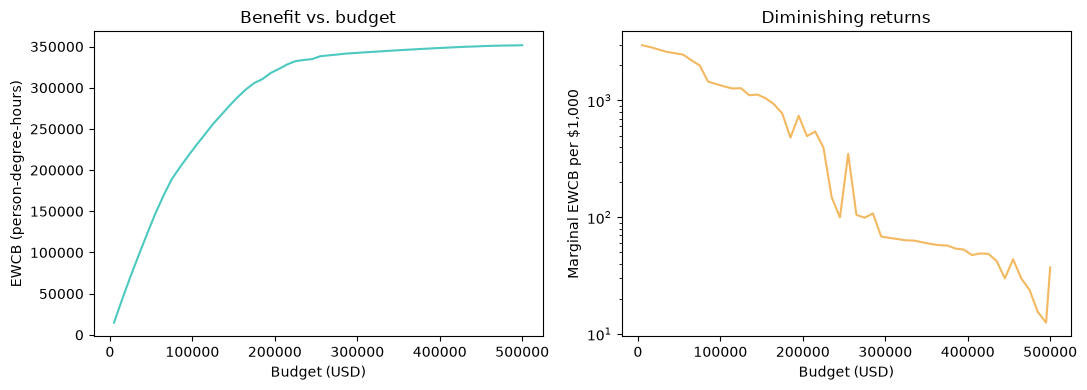

Marginal value falls from 2973.8 at $5,000 to 37.2 at $500,000


In [6]:
from engine.optimize.frontier import compute_efficient_frontier

frontier = compute_efficient_frontier(objective, costs)

budgets = [p.budget_usd for p in frontier]
values = [p.objective_value for p in frontier]
marginals = [p.marginal_value_per_1000usd for p in frontier]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(budgets, values, color="#4cc9c0")
ax1.set_xlabel("Budget (USD)")
ax1.set_ylabel("EWCB (person-degree-hours)")
ax1.set_title("Benefit vs. budget")

ax2.plot(budgets, marginals, color="#f4b860")
ax2.set_xlabel("Budget (USD)")
ax2.set_ylabel("Marginal EWCB per $1,000")
ax2.set_title("Diminishing returns")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Marginal value falls from {marginals[0]:.1f} at ${budgets[0]:,.0f} to {marginals[-1]:.1f} at ${budgets[-1]:,.0f}")

## E5: the baselines -- "the proof the product works"

Spread evenly, worst-first, squeaky wheel, TES-score-only, and CoolBlock,
all scored by the same real coverage objective.

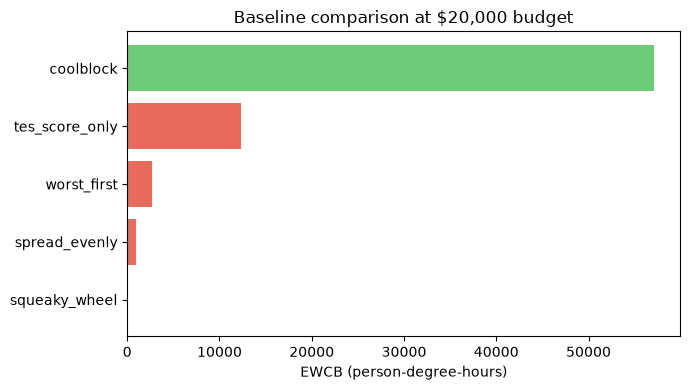

CoolBlock beats TES-score-only (the best existing tool) by 4.6x


In [7]:
from engine.optimize.baselines import run_all_baselines

results = run_all_baselines(candidates, objective, costs, budget_usd=BUDGET)
results_sorted = dict(sorted(results.items(), key=lambda kv: kv[1]))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#e86a5c" if k != "coolblock" else "#6bcb77" for k in results_sorted]
ax.barh(list(results_sorted.keys()), list(results_sorted.values()), color=colors)
ax.set_xlabel("EWCB (person-degree-hours)")
ax.set_title(f"Baseline comparison at ${BUDGET:,.0f} budget")
plt.tight_layout()
plt.show()

uplift = results["coolblock"] / results["tes_score_only"]
print(f"CoolBlock beats TES-score-only (the best existing tool) by {uplift:.1f}x")

## Summary

- **E1**: real submodular coverage objective (`max`, not `sum`, on overlap).
- **E2**: three solvers -- CELF greedy, exact MILP (HiGHS), local search --
  all measured against each other on real data, not asserted.
- **E3**: five real constraints (budget, maintenance cap, equity floor,
  dispersion cap, public-land-only); two disclosed as not implementable
  (species diversity, water budget) given this project's actual data.
- **E4**: a real diminishing-returns curve across the plan's own
  $5k-$500k range.
- **E5**: CoolBlock beats every baseline, including TES-score-only, by a
  clear margin at real budgets.
- A genuinely important, disclosed limitation: the unconstrained solve is
  cool-roof-heavy because C1 and C3's ΔT values are not on a comparable
  physical basis -- investigated and stated plainly, not patched with an
  invented number (`docs/adr/0014-*.md`).

Deferred: Wolfram `NMaximize` independent cross-check (no Wolfram access
this session, `docs/adr/0002-*.md`).